In [43]:
from itertools import product
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from scaling.visualize import visualize_train_curves, plot_line_fit, plot_isoflops
from pathlib import Path

In [44]:
unique_col_list = ["base_N", "target_N", "tkpm", "shrink", "method"]
y_col = "Validation Loss"
x_col = "flops"


def preprocess_warmstarting(df, y_col_to_smooth=None, smoothing_window=100):
    __df = pd.DataFrame()
    for i, x in enumerate(df.groupby(unique_col_list)):
        _df = x[1].sort_values(by="flops")
        # smooth it
        if y_col_to_smooth is not None:
            # +"_smoothed"
            _df[y_col_to_smooth] = _df[y_col_to_smooth].rolling(smoothing_window, win_type='gaussian', min_periods=1).mean(std=smoothing_window / 10)
        
        # scaling tokens and flops to the max
        max_intended_tokens = (_df.iloc[-1]["target_N"] * _df.iloc[-1]["tkpm"])
        if abs((max_intended_tokens -  _df["tokens"].max()) / _df["tokens"].max()) > 0.01:
            print("Wrong tkpm: ", x[0])
            continue
        _df["tokens"] = np.round(max_intended_tokens / _df["tokens"].max() * _df["tokens"])
        
        max_intended_flops = 6. * max_intended_tokens * _df["target_N"]
        _df["flops"] = np.round(max_intended_flops / _df["flops"].max() * _df["flops"])
        
        __df = pd.concat([__df, _df])
    
    print('Droping tkpm <= 5')    
    __df = __df[__df['tkpm'] > 5.]
    
    return __df

   
def get_loss_at_flops(df: pd.DataFrame, flop_intervals: list[float], y_col: str, unique_col_list = list[str], add_base_compute=False) -> pd.Series:
    """Get the loss at a specific flop value by interpolation."""
    x_col = "flops"
    best_learning_curve = None
    best_final_loss = float('inf')

    for i, x in enumerate(df.groupby(unique_col_list)):
        _df = x[1].dropna(subset=[y_col]).sort_values(by=x_col)
        if add_base_compute:
            base_flops = 6. * 20. * _df.iloc[0]['base_N']**2
            _df[x_col] += base_flops
        final_loss = _df.iloc[-1][y_col]
        if final_loss < best_final_loss:
            best_final_loss = final_loss
            best_learning_curve = pd.Series(
                data=_df[y_col].values,
                index=_df[x_col].values
            )
    
    # add the flops into the Series if not present
    for flop in flop_intervals:
        if flop not in best_learning_curve.index:
            best_learning_curve.loc[flop] = np.nan
    best_learning_curve = best_learning_curve.sort_index()
    # interpolate nans
    best_learning_curve = best_learning_curve.interpolate(method='linear')
    return best_learning_curve.loc[flop_intervals]

In [45]:
warmstarting_df = pd.read_parquet(
    "../data/warmstart_runs_flattened.parquet",
)
warmstarting_df = warmstarting_df.dropna(subset=[y_col])
warmstarting_df = preprocess_warmstarting(warmstarting_df)

Wrong tkpm:  (77124608, 1217722368, 10.0, 0.0, 'mup')
Droping tkpm <= 5


In [47]:
warmstarting_df['method'].unique()

<ArrowStringArray>
['mup', 'paws', 'net2net']
Length: 3, dtype: str

In [35]:
test_df = pd.read_parquet(
    "../data/warmstart_runs_flattened.parquet",
)

# select method mup with the largest tokens available and the max steps and flops
# warmstarting_df = warmstarting_df[warmstarting_df['method'] == 'mup']
test_df = test_df[test_df['target_N'] == 1217722368]
test_df = test_df.sort_values(by=['flops'], ascending=[False])
# warmstarting_df.dropna(subset=[y_col])

In [39]:
test_df['tokens'] / test_df['target_N']

1931096    1.036666
1931095    1.035818
1931094    1.034970
1931093    1.034123
1931092    1.033275
             ...   
1931101    1.040904
1931100    1.040056
1931099    1.039208
1931098    1.038361
1931097    1.037513
Length: 3171, dtype: float64

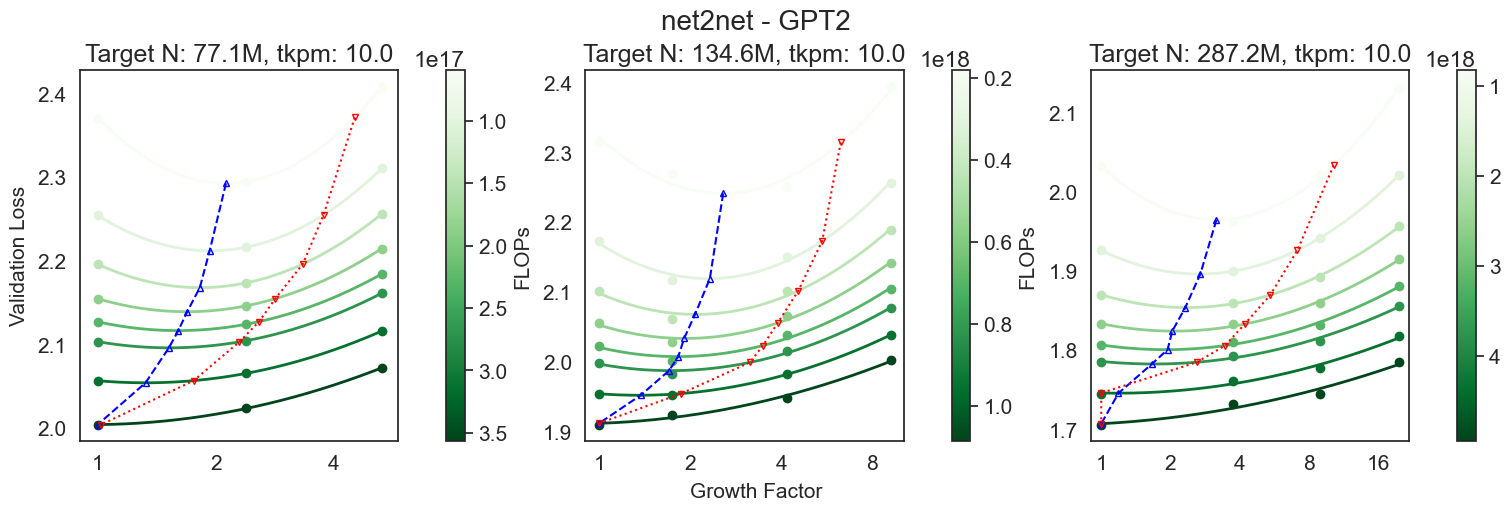

In [62]:
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook", font_scale=1.5)

ADD_BASE_COMPUTE = False
TKPM = 10.
MIN_FLOPS_SCALE_FACTOR = 6
NUM_FLOP_INTERVALS = 8
METHOD = 'net2net'
SHRINK = None
TARGET_RANGE_L = 1
TARGET_RANGE_R = 5

warmstarting_tkpms_df = warmstarting_df[warmstarting_df['tkpm']==TKPM]
method_tkpms_df = warmstarting_tkpms_df[warmstarting_tkpms_df['method']==METHOD]

target_models = sorted(method_tkpms_df['target_N'].unique())
target_models = target_models[TARGET_RANGE_L:TARGET_RANGE_R]  # skip the smallest model
fig, axes = plt.subplots(1, len(target_models), figsize=(5 * len(target_models), 5), layout='constrained')
axes = np.atleast_1d(axes)

tables = {}
for i, target_model in enumerate(target_models):
    target_model_df = warmstarting_tkpms_df[warmstarting_tkpms_df['target_N']==target_model]
    no_growth_df = target_model_df[target_model_df['method']=='mup']
    
    # calculate flop intervals
    max_flops = no_growth_df['flops'].max()
    min_flops = max_flops / MIN_FLOPS_SCALE_FACTOR
    flop_intervals = np.linspace(min_flops, max_flops, NUM_FLOP_INTERVALS)
    flops_df = pd.DataFrame()
    
    # add growth factor == 1
    no_growth_df = no_growth_df[no_growth_df["base_N"]==no_growth_df["base_N"].max()]
    flops_df[1.] = get_loss_at_flops(no_growth_df, flop_intervals, y_col, unique_col_list)
    
    # add growth factor > 1
    shrink_target_model_df = target_model_df[target_model_df['method'] == METHOD]
    if SHRINK is not None:
        shrink_target_model_df = shrink_target_model_df[shrink_target_model_df['shrink']==SHRINK]
    # check if it is in a shrink list
    
    base_models = sorted(shrink_target_model_df['base_N'].unique(), reverse=True)
    for base_model in base_models:
        base_model_df = shrink_target_model_df[shrink_target_model_df['base_N']==base_model]
        
        growth_factor = target_model / base_model
        growth_df = base_model_df[base_model_df['target_N']==target_model]
        flops_df[growth_factor] = get_loss_at_flops(growth_df, flop_intervals, y_col, unique_col_list, add_base_compute=ADD_BASE_COMPUTE)
        # select only the shrink factor we want
    axes[i].set_title(f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}")
    table_df = plot_isoflops(
        axes[i],
        flops_df,
        disable_y_label=(i == len(target_models) - 1),
        return_table=True,
    )
    tables[f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}"] = table_df
    
# add figure wide xlabel
fig.supxlabel("Growth Factor", fontsize=15)
fig.supylabel(y_col, fontsize=15)
fig.suptitle(f"{METHOD} - GPT2", fontsize=20)
# save the figure in a great resulution
fig.savefig(f"figures/neurips_{METHOD}_{TKPM}-tkpm_isoflops_.pdf")

# create a markdown file for each table
for title, table_df in tables.items():
    table_df.index = table_df.index.map(lambda x: f"{x:.1e}")
    for col in table_df.columns:
        table_df[col] = table_df[col].map(lambda x: f"{x:.1f}")
                                          
    Path(f"tables/rebuttal_isoflops_net2net/{title}.md").parent.mkdir(parents=True, exist_ok=True)
    table_df.to_markdown(f"tables/rebuttal_isoflops_net2net/{title}.md")


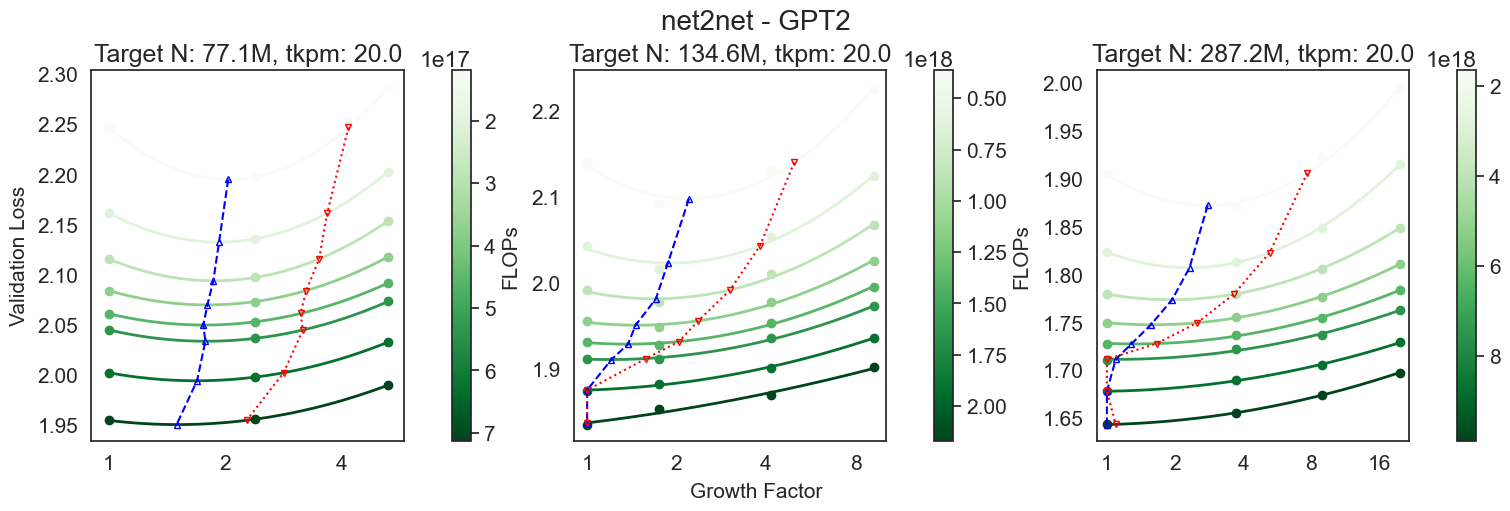

In [67]:
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook", font_scale=1.5)

ADD_BASE_COMPUTE = False
TKPM = 20.
MIN_FLOPS_SCALE_FACTOR = 6
NUM_FLOP_INTERVALS = 8
METHOD = 'net2net'
SHRINK = None
TARGET_RANGE_L = 1
TARGET_RANGE_R = 4

warmstarting_tkpms_df = warmstarting_df[warmstarting_df['tkpm']==TKPM]
method_tkpms_df = warmstarting_tkpms_df[warmstarting_tkpms_df['method']==METHOD]

target_models = sorted(method_tkpms_df['target_N'].unique())
target_models = target_models[TARGET_RANGE_L:TARGET_RANGE_R]  # skip the smallest model
fig, axes = plt.subplots(1, len(target_models), figsize=(5 * len(target_models), 5), layout='constrained')
axes = np.atleast_1d(axes)

tables = {}
for i, target_model in enumerate(target_models):
    target_model_df = warmstarting_tkpms_df[warmstarting_tkpms_df['target_N']==target_model]
    no_growth_df = target_model_df[target_model_df['method']=='mup']

    # calculate flop intervals
    max_flops = no_growth_df['flops'].max()
    min_flops = max_flops / MIN_FLOPS_SCALE_FACTOR
    flop_intervals = np.linspace(min_flops, max_flops, NUM_FLOP_INTERVALS)
    flops_df = pd.DataFrame()

    # add growth factor == 1
    no_growth_df = no_growth_df[no_growth_df["base_N"]==no_growth_df["base_N"].max()]
    flops_df[1.] = get_loss_at_flops(no_growth_df, flop_intervals, y_col, unique_col_list)

    # add growth factor > 1
    shrink_target_model_df = target_model_df[target_model_df['method'] == METHOD]
    if SHRINK is not None:
        shrink_target_model_df = shrink_target_model_df[shrink_target_model_df['shrink']==SHRINK]
    # check if it is in a shrink list

    base_models = sorted(shrink_target_model_df['base_N'].unique(), reverse=True)
    for base_model in base_models:
        base_model_df = shrink_target_model_df[shrink_target_model_df['base_N']==base_model]

        growth_factor = target_model / base_model
        growth_df = base_model_df[base_model_df['target_N']==target_model]
        flops_df[growth_factor] = get_loss_at_flops(growth_df, flop_intervals, y_col, unique_col_list, add_base_compute=ADD_BASE_COMPUTE)
        # select only the shrink factor we want
    axes[i].set_title(f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}")
    table_df = plot_isoflops(
        axes[i],
        flops_df,
        disable_y_label=(i == len(target_models) - 1),
        return_table=True,
    )
    tables[f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}"] = table_df

# add figure wide xlabel
fig.supxlabel("Growth Factor", fontsize=15)
fig.supylabel(y_col, fontsize=15)
fig.suptitle(f"{METHOD} - GPT2", fontsize=20)
# save the figure in a great resulution
fig.savefig(f"figures/neurips_{METHOD}_{TKPM}-tkpm_isoflops_.pdf")

# create a markdown file for each table
for title, table_df in tables.items():
    table_df.index = table_df.index.map(lambda x: f"{x:.1e}")
    for col in table_df.columns:
        table_df[col] = table_df[col].map(lambda x: f"{x:.1f}")

    Path(f"tables/rebuttal_isoflops_net2net/{title}.md").parent.mkdir(parents=True, exist_ok=True)
    table_df.to_markdown(f"tables/rebuttal_isoflops_net2net/{title}.md")


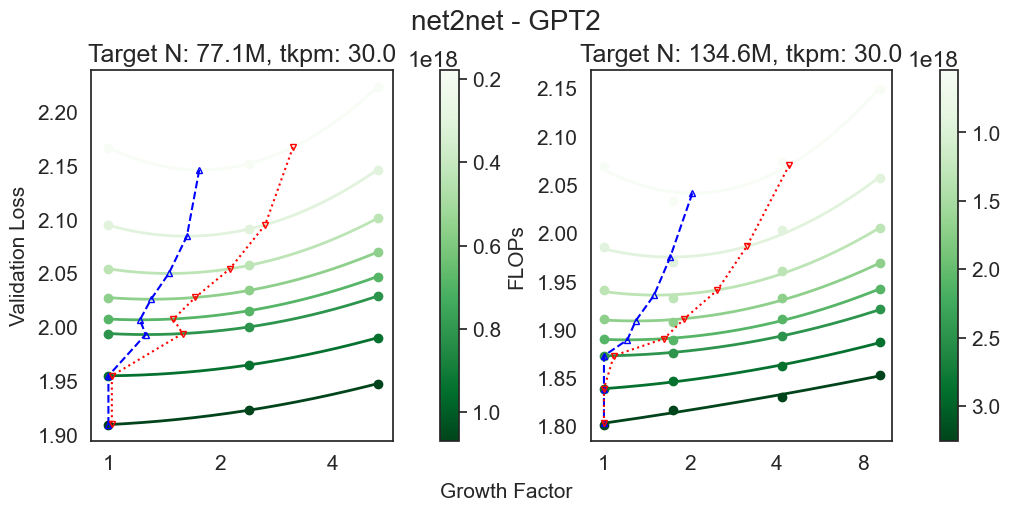

In [72]:
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook", font_scale=1.5)

ADD_BASE_COMPUTE = False
TKPM = 30.
MIN_FLOPS_SCALE_FACTOR = 6
NUM_FLOP_INTERVALS = 8
METHOD = 'net2net'
SHRINK = None
TARGET_RANGE_L = 1
TARGET_RANGE_R = 10

warmstarting_tkpms_df = warmstarting_df[warmstarting_df['tkpm']==TKPM]
method_tkpms_df = warmstarting_tkpms_df[warmstarting_tkpms_df['method']==METHOD]

target_models = sorted(method_tkpms_df['target_N'].unique())
target_models = target_models[TARGET_RANGE_L:TARGET_RANGE_R]  # skip the smallest model
fig, axes = plt.subplots(1, len(target_models), figsize=(5 * len(target_models), 5), layout='constrained')
axes = np.atleast_1d(axes)

tables = {}
for i, target_model in enumerate(target_models):
    target_model_df = warmstarting_tkpms_df[warmstarting_tkpms_df['target_N']==target_model]
    no_growth_df = target_model_df[target_model_df['method']=='mup']

    # calculate flop intervals
    max_flops = no_growth_df['flops'].max()
    min_flops = max_flops / MIN_FLOPS_SCALE_FACTOR
    flop_intervals = np.linspace(min_flops, max_flops, NUM_FLOP_INTERVALS)
    flops_df = pd.DataFrame()

    # add growth factor == 1
    no_growth_df = no_growth_df[no_growth_df["base_N"]==no_growth_df["base_N"].max()]
    flops_df[1.] = get_loss_at_flops(no_growth_df, flop_intervals, y_col, unique_col_list)

    # add growth factor > 1
    shrink_target_model_df = target_model_df[target_model_df['method'] == METHOD]
    if SHRINK is not None:
        shrink_target_model_df = shrink_target_model_df[shrink_target_model_df['shrink']==SHRINK]
    # check if it is in a shrink list

    base_models = sorted(shrink_target_model_df['base_N'].unique(), reverse=True)
    for base_model in base_models:
        base_model_df = shrink_target_model_df[shrink_target_model_df['base_N']==base_model]

        growth_factor = target_model / base_model
        growth_df = base_model_df[base_model_df['target_N']==target_model]
        flops_df[growth_factor] = get_loss_at_flops(growth_df, flop_intervals, y_col, unique_col_list, add_base_compute=ADD_BASE_COMPUTE)
        # select only the shrink factor we want
    axes[i].set_title(f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}")
    table_df = plot_isoflops(
        axes[i],
        flops_df,
        disable_y_label=(i == len(target_models) - 1),
        return_table=True,
    )
    tables[f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}"] = table_df

# add figure wide xlabel
fig.supxlabel("Growth Factor", fontsize=15)
fig.supylabel(y_col, fontsize=15)
fig.suptitle(f"{METHOD} - GPT2", fontsize=20)
# save the figure in a great resulution
fig.savefig(f"figures/neurips_{METHOD}_{TKPM}-tkpm_isoflops_.pdf")

# create a markdown file for each table
for title, table_df in tables.items():
    table_df.index = table_df.index.map(lambda x: f"{x:.1e}")
    for col in table_df.columns:
        table_df[col] = table_df[col].map(lambda x: f"{x:.1f}")

    Path(f"tables/rebuttal_isoflops_net2net/{title}.md").parent.mkdir(parents=True, exist_ok=True)
    table_df.to_markdown(f"tables/rebuttal_isoflops_net2net/{title}.md")

,1.000000,1.744726,4.169747,9.240221
3.621348e+17,2.072072,2.093328,2.130461,2.226164
6.208024e+17,1.978751,2.016786,2.054052,2.124067
8.794701e+17,1.926862,1.977272,2.009953,2.067868
1.138138e+18,1.893606,1.948477,1.977732,2.026026
1.396806e+18,1.869682,1.927657,1.953669,1.995797
1.655473e+18,1.850389,1.911424,1.935570,1.973014
1.914141e+18,1.813679,1.882279,1.901550,1.936313
2.172809e+18,1.775524,1.852917,1.869150,1.901763


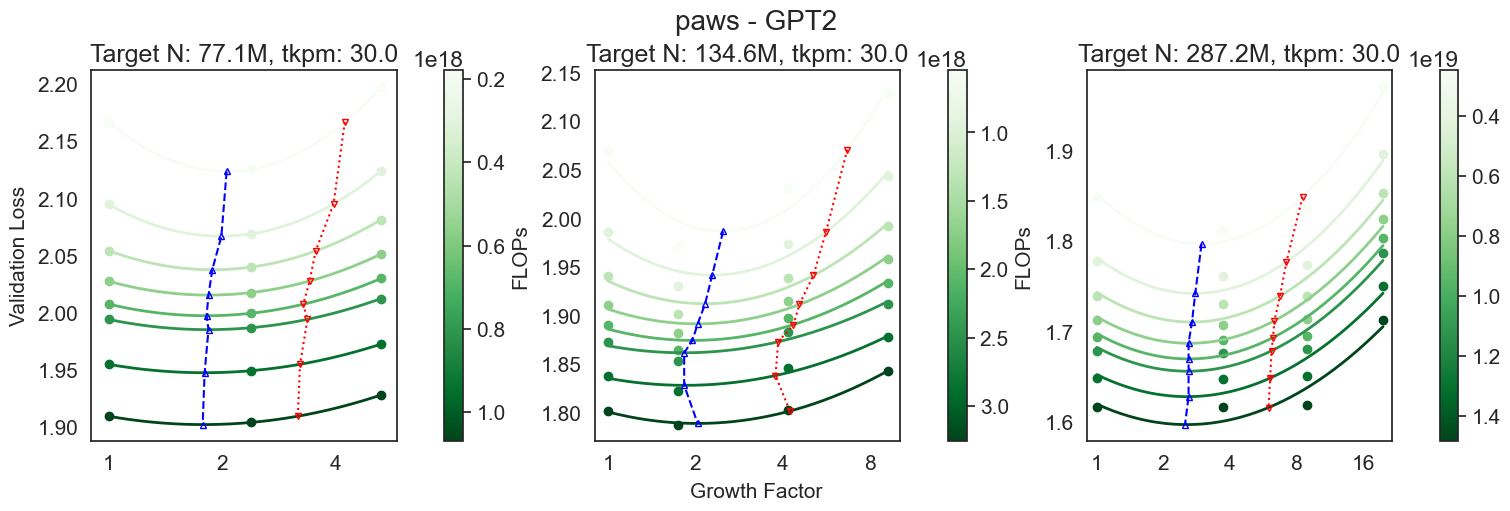

In [75]:
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook", font_scale=1.5)

ADD_BASE_COMPUTE = False
TKPM = 30.
MIN_FLOPS_SCALE_FACTOR = 6
NUM_FLOP_INTERVALS = 8
METHOD = 'paws'
SHRINK = 0.4
TARGET_RANGE_L = 1
TARGET_RANGE_R = 4

warmstarting_tkpms_df = warmstarting_df[warmstarting_df['tkpm']==TKPM]
method_tkpms_df = warmstarting_tkpms_df[warmstarting_tkpms_df['method']==METHOD]

target_models = sorted(method_tkpms_df['target_N'].unique())
target_models = target_models[TARGET_RANGE_L:TARGET_RANGE_R]  # skip the smallest model
fig, axes = plt.subplots(1, len(target_models), figsize=(5 * len(target_models), 5), layout='constrained')
axes = np.atleast_1d(axes)

tables = {}
for i, target_model in enumerate(target_models):
    target_model_df = warmstarting_tkpms_df[warmstarting_tkpms_df['target_N']==target_model]
    no_growth_df = target_model_df[target_model_df['method']=='mup']

    # calculate flop intervals
    max_flops = no_growth_df['flops'].max()
    min_flops = max_flops / MIN_FLOPS_SCALE_FACTOR
    flop_intervals = np.linspace(min_flops, max_flops, NUM_FLOP_INTERVALS)
    flops_df = pd.DataFrame()

    # add growth factor == 1
    no_growth_df = no_growth_df[no_growth_df["base_N"]==no_growth_df["base_N"].max()]
    flops_df[1.] = get_loss_at_flops(no_growth_df, flop_intervals, y_col, unique_col_list)

    # add growth factor > 1
    shrink_target_model_df = target_model_df[target_model_df['method'] == METHOD]
    if SHRINK is not None:
        shrink_target_model_df = shrink_target_model_df[shrink_target_model_df['shrink']==SHRINK]
    # check if it is in a shrink list

    base_models = sorted(shrink_target_model_df['base_N'].unique(), reverse=True)
    for base_model in base_models:
        base_model_df = shrink_target_model_df[shrink_target_model_df['base_N']==base_model]

        growth_factor = target_model / base_model
        growth_df = base_model_df[base_model_df['target_N']==target_model]
        flops_df[growth_factor] = get_loss_at_flops(growth_df, flop_intervals, y_col, unique_col_list, add_base_compute=ADD_BASE_COMPUTE)
        # select only the shrink factor we want
    axes[i].set_title(f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}")
    table_df = plot_isoflops(
        axes[i],
        flops_df,
        disable_y_label=(i == len(target_models) - 1),
        return_table=True,
    )
    tables[f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}"] = table_df

# add figure wide xlabel
fig.supxlabel("Growth Factor", fontsize=15)
fig.supylabel(y_col, fontsize=15)
fig.suptitle(f"{METHOD} - GPT2", fontsize=20)
# save the figure in a great resulution
fig.savefig(f"figures/neurips_{METHOD}_{TKPM}-tkpm_isoflops_.pdf")

# create a markdown file for each table
for title, table_df in tables.items():
    table_df.index = table_df.index.map(lambda x: f"{x:.1e}")
    for col in table_df.columns:
        table_df[col] = table_df[col].map(lambda x: f"{x:.1f}")

    Path(f"tables/rebuttal_isoflops_net2net/{title}.md").parent.mkdir(parents=True, exist_ok=True)
    table_df.to_markdown(f"tables/rebuttal_isoflops_net2net/{title}.md")

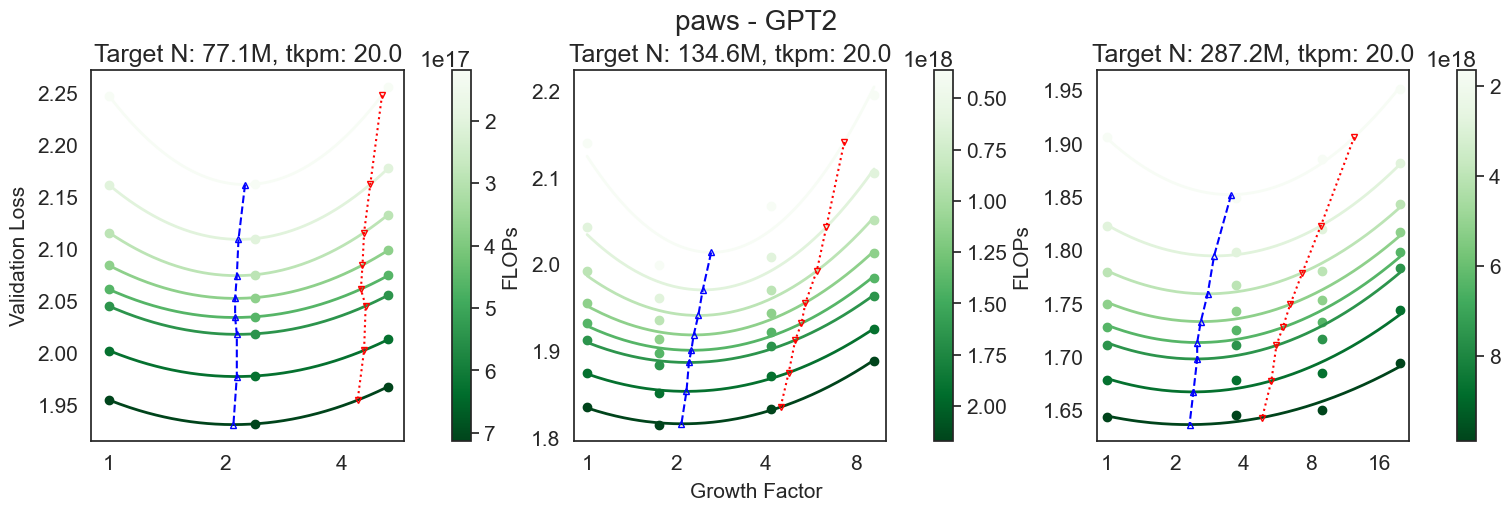

In [80]:
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook", font_scale=1.5)

ADD_BASE_COMPUTE = False
TKPM = 20.
MIN_FLOPS_SCALE_FACTOR = 6
NUM_FLOP_INTERVALS = 8
METHOD = 'paws'
SHRINK = 0.4
TARGET_RANGE_L = 1
TARGET_RANGE_R = 4

warmstarting_tkpms_df = warmstarting_df[warmstarting_df['tkpm']==TKPM]
method_tkpms_df = warmstarting_tkpms_df[warmstarting_tkpms_df['method']==METHOD]

target_models = sorted(method_tkpms_df['target_N'].unique())
target_models = target_models[TARGET_RANGE_L:TARGET_RANGE_R]  # skip the smallest model
fig, axes = plt.subplots(1, len(target_models), figsize=(5 * len(target_models), 5), layout='constrained')
axes = np.atleast_1d(axes)

tables = {}
for i, target_model in enumerate(target_models):
    target_model_df = warmstarting_tkpms_df[warmstarting_tkpms_df['target_N']==target_model]
    no_growth_df = target_model_df[target_model_df['method']=='mup']

    # calculate flop intervals
    max_flops = no_growth_df['flops'].max()
    min_flops = max_flops / MIN_FLOPS_SCALE_FACTOR
    flop_intervals = np.linspace(min_flops, max_flops, NUM_FLOP_INTERVALS)
    flops_df = pd.DataFrame()

    # add growth factor == 1
    no_growth_df = no_growth_df[no_growth_df["base_N"]==no_growth_df["base_N"].max()]
    flops_df[1.] = get_loss_at_flops(no_growth_df, flop_intervals, y_col, unique_col_list)

    # add growth factor > 1
    shrink_target_model_df = target_model_df[target_model_df['method'] == METHOD]
    if SHRINK is not None:
        shrink_target_model_df = shrink_target_model_df[shrink_target_model_df['shrink']==SHRINK]
    # check if it is in a shrink list

    base_models = sorted(shrink_target_model_df['base_N'].unique(), reverse=True)
    for base_model in base_models:
        base_model_df = shrink_target_model_df[shrink_target_model_df['base_N']==base_model]

        growth_factor = target_model / base_model
        growth_df = base_model_df[base_model_df['target_N']==target_model]
        flops_df[growth_factor] = get_loss_at_flops(growth_df, flop_intervals, y_col, unique_col_list, add_base_compute=ADD_BASE_COMPUTE)
        # select only the shrink factor we want
    axes[i].set_title(f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}")
    table_df = plot_isoflops(
        axes[i],
        flops_df,
        disable_y_label=(i == len(target_models) - 1),
        return_table=True,
    )
    tables[f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}"] = table_df

# add figure wide xlabel
fig.supxlabel("Growth Factor", fontsize=15)
fig.supylabel(y_col, fontsize=15)
fig.suptitle(f"{METHOD} - GPT2", fontsize=20)
# save the figure in a great resulution
fig.savefig(f"figures/neurips_{METHOD}_{TKPM}-tkpm_isoflops_.pdf")

# create a markdown file for each table
for title, table_df in tables.items():
    table_df.index = table_df.index.map(lambda x: f"{x:.1e}")
    for col in table_df.columns:
        table_df[col] = table_df[col].map(lambda x: f"{x:.1f}")

    Path(f"tables/rebuttal_isoflops_net2net/{title}.md").parent.mkdir(parents=True, exist_ok=True)
    table_df.to_markdown(f"tables/rebuttal_isoflops_net2net/{title}.md")

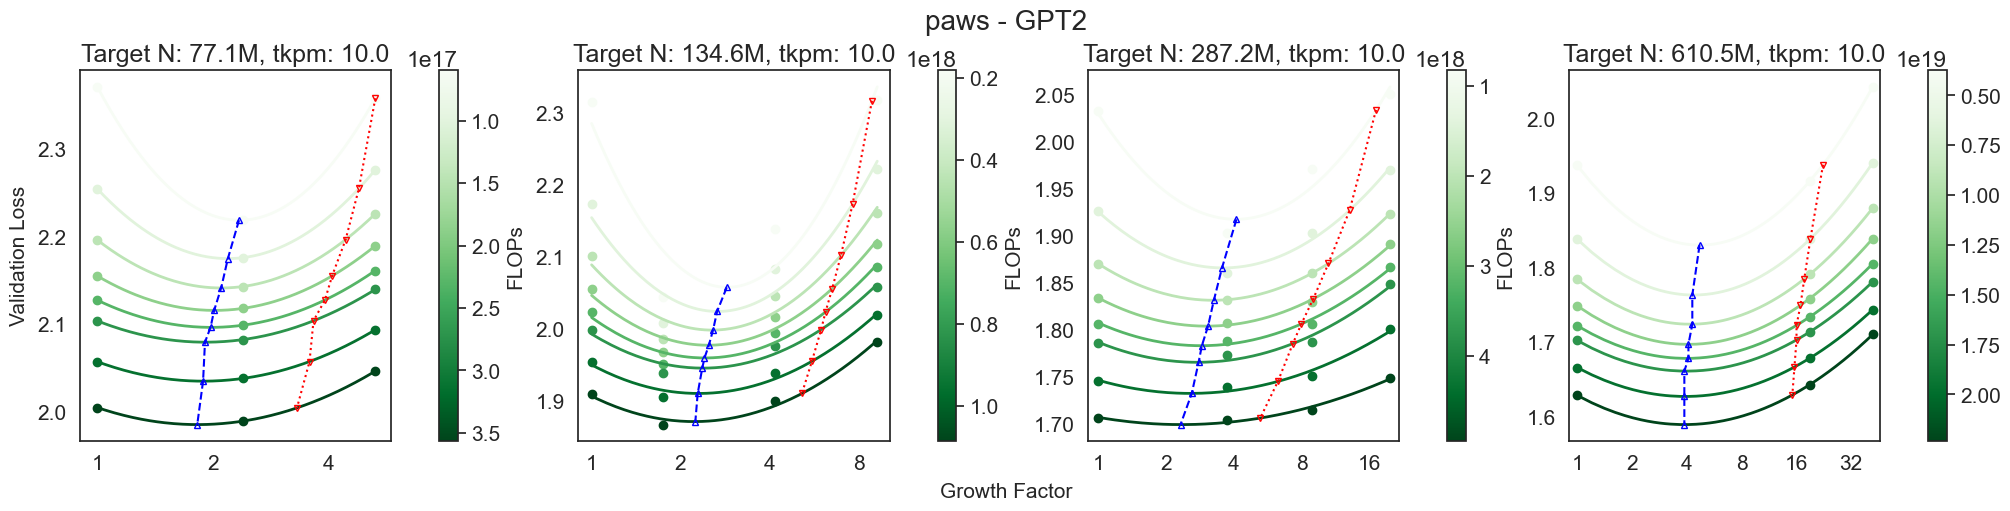

In [83]:
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook", font_scale=1.5)

ADD_BASE_COMPUTE = False
TKPM = 10.
MIN_FLOPS_SCALE_FACTOR = 6
NUM_FLOP_INTERVALS = 8
METHOD = 'paws'
SHRINK = 0.4
TARGET_RANGE_L = 1
TARGET_RANGE_R = 10

warmstarting_tkpms_df = warmstarting_df[warmstarting_df['tkpm']==TKPM]
method_tkpms_df = warmstarting_tkpms_df[warmstarting_tkpms_df['method']==METHOD]

target_models = sorted(method_tkpms_df['target_N'].unique())
target_models = target_models[TARGET_RANGE_L:TARGET_RANGE_R]  # skip the smallest model
fig, axes = plt.subplots(1, len(target_models), figsize=(5 * len(target_models), 5), layout='constrained')
axes = np.atleast_1d(axes)

tables = {}
for i, target_model in enumerate(target_models):
    target_model_df = warmstarting_tkpms_df[warmstarting_tkpms_df['target_N']==target_model]
    no_growth_df = target_model_df[target_model_df['method']=='mup']

    # calculate flop intervals
    max_flops = no_growth_df['flops'].max()
    min_flops = max_flops / MIN_FLOPS_SCALE_FACTOR
    flop_intervals = np.linspace(min_flops, max_flops, NUM_FLOP_INTERVALS)
    flops_df = pd.DataFrame()

    # add growth factor == 1
    no_growth_df = no_growth_df[no_growth_df["base_N"]==no_growth_df["base_N"].max()]
    flops_df[1.] = get_loss_at_flops(no_growth_df, flop_intervals, y_col, unique_col_list)

    # add growth factor > 1
    shrink_target_model_df = target_model_df[target_model_df['method'] == METHOD]
    if SHRINK is not None:
        shrink_target_model_df = shrink_target_model_df[shrink_target_model_df['shrink']==SHRINK]
    # check if it is in a shrink list

    base_models = sorted(shrink_target_model_df['base_N'].unique(), reverse=True)
    for base_model in base_models:
        base_model_df = shrink_target_model_df[shrink_target_model_df['base_N']==base_model]

        growth_factor = target_model / base_model
        growth_df = base_model_df[base_model_df['target_N']==target_model]
        flops_df[growth_factor] = get_loss_at_flops(growth_df, flop_intervals, y_col, unique_col_list, add_base_compute=ADD_BASE_COMPUTE)
        # select only the shrink factor we want
    axes[i].set_title(f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}")
    table_df = plot_isoflops(
        axes[i],
        flops_df,
        disable_y_label=(i == len(target_models) - 1),
        return_table=True,
    )
    tables[f"Target N: {(target_model/1_000_000):3.1f}M, tkpm: {TKPM}"] = table_df

# add figure wide xlabel
fig.supxlabel("Growth Factor", fontsize=15)
fig.supylabel(y_col, fontsize=15)
fig.suptitle(f"{METHOD} - GPT2", fontsize=20)
# save the figure in a great resulution
fig.savefig(f"figures/neurips_{METHOD}_{TKPM}-tkpm_isoflops_.pdf")

# create a markdown file for each table
for title, table_df in tables.items():
    table_df.index = table_df.index.map(lambda x: f"{x:.1e}")
    for col in table_df.columns:
        table_df[col] = table_df[col].map(lambda x: f"{x:.1f}")

    Path(f"tables/rebuttal_isoflops_net2net/{title}.md").parent.mkdir(parents=True, exist_ok=True)
    table_df.to_markdown(f"tables/rebuttal_isoflops_net2net/{title}.md")